##### Copyright 2020 The TensorFlow Authors.

In [18]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Simple audio recognition: Recognizing keywords

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/tutorials/audio/simple_audio">
    <img src="https://www.tensorflow.org/images/tf_logo_32px.png" />
    View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/audio/simple_audio.ipynb">
    <img src="https://www.tensorflow.org/images/colab_logo_32px.png" />
    Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/docs/blob/master/site/en/tutorials/audio/simple_audio.ipynb">
    <img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />
    View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/docs/site/en/tutorials/audio/simple_audio.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>

This tutorial demonstrates how to preprocess audio files in the WAV format and build and train a basic [automatic speech recognition](https://en.wikipedia.org/wiki/Speech_recognition) (ASR) model for recognizing ten different words. You will use a portion of the [Speech Commands dataset](https://www.tensorflow.org/datasets/catalog/speech_commands) ([Warden, 2018](https://arxiv.org/abs/1804.03209)), which contains short (one-second or less) audio clips of commands, such as "down", "go", "left", "no", "right", "stop", "up" and "yes".

Real-world speech and audio recognition [systems](https://ai.googleblog.com/search/label/Speech%20Recognition) are complex. But, like [image classification with the MNIST dataset](../quickstart/beginner.ipynb), this tutorial should give you a basic understanding of the techniques involved.

## Setup

Import necessary modules and dependencies. You'll be using `tf.keras.utils.audio_dataset_from_directory` (introduced in TensorFlow 2.10), which helps generate audio classification datasets from directories of `.wav` files. You'll also need [seaborn](https://seaborn.pydata.org) for visualization in this tutorial.

In [19]:
!pip install -U -q tensorflow tensorflow_datasets
!pip install ai_edge_litert

In [20]:
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from IPython import display

# Set the seed value for experiment reproducibility.
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

## Import the mini Speech Commands dataset

To save time with data loading, you will be working with a smaller version of the Speech Commands dataset. The [original dataset](https://www.tensorflow.org/datasets/catalog/speech_commands) consists of over 105,000 audio files in the [WAV (Waveform) audio file format](https://www.aelius.com/njh/wavemetatools/doc/riffmci.pdf) of people saying 35 different words. This data was collected by Google and released under a CC BY license.

Download and extract the `mini_speech_commands.zip` file containing the smaller Speech Commands datasets with `tf.keras.utils.get_file`:

In [21]:
DATASET_PATH = tf.keras.utils.get_file(
      'mini_speech_commands.zip',
      origin="http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip",
      extract=True,
      cache_dir='.', cache_subdir='data')
data_dir = pathlib.Path(DATASET_PATH) / 'mini_speech_commands'

### Generate Synthetic `_noise_` and `_silence_` Classes

We create synthetic WAV files so the model can learn to reject non-speech input.

In [23]:
"""
generate_noise_silence.py
─────────────────────────
Drop-in replacement for the simple noise/silence generator.
Produces 10 acoustically distinct variants so the model learns
to reject the full range of real-world non-speech sounds.

Usage (in your notebook cell):
    exec(open('generate_noise_silence.py').read())
    # or paste the code directly into a cell
"""

import wave, struct, random, math
import numpy as np
import scipy.signal
import pathlib

# ── assumes data_dir is already defined (pathlib.Path) ──
# data_dir = pathlib.Path('data/mini_speech_commands')

SAMPLE_RATE = 16000
N_SAMPLES   = 16000   # 1 second
N_FILES     = 300     # per class  (30 files × 10 variants = 300 total)
FILES_PER_VARIANT = N_FILES // 10  # 30


# ═══════════════════════════════════════════════
#  Low-level helpers
# ═══════════════════════════════════════════════

def _norm(arr, target_rms=0.1):
    """Normalise array to a target RMS, avoid div-by-zero."""
    rms = np.sqrt(np.mean(arr ** 2)) + 1e-9
    return arr * (target_rms / rms)

def _to_int16(arr):
    """Float [-1,1] → int16 list."""
    arr = np.clip(arr, -1.0, 1.0)
    return (arr * 32767).astype(np.int16).tolist()

def write_wav(path, samples_float, sample_rate=SAMPLE_RATE):
    path = pathlib.Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    int16 = _to_int16(samples_float)
    with wave.open(str(path), 'w') as wf:
        wf.setnchannels(1)
        wf.setsampwidth(2)
        wf.setframerate(sample_rate)
        wf.writeframes(b''.join(struct.pack('<h', s) for s in int16))


# ═══════════════════════════════════════════════
#  NOISE generators  (10 variants)
# ═══════════════════════════════════════════════

def gen_white_noise(n=N_SAMPLES):
    """Flat spectrum — baseline."""
    amp = random.uniform(0.05, 1.0)
    return _norm(np.random.randn(n) * amp)

def gen_pink_noise(n=N_SAMPLES):
    """1/f spectrum — closer to natural ambient sound."""
    white = np.random.randn(n)
    # Voss-McCartney approximation via cumulative sum of decimated series
    freqs  = np.fft.rfftfreq(n)
    freqs[0] = 1e-6
    power  = 1.0 / np.sqrt(freqs)
    fft_w  = np.fft.rfft(white)
    pink   = np.fft.irfft(fft_w * power, n=n)
    return _norm(pink)

def gen_brown_noise(n=N_SAMPLES):
    """1/f² (red noise) — deep rumble / HVAC / fan."""
    white  = np.random.randn(n)
    freqs  = np.fft.rfftfreq(n)
    freqs[0] = 1e-6
    power  = 1.0 / freqs
    fft_w  = np.fft.rfft(white)
    brown  = np.fft.irfft(fft_w * power, n=n)
    return _norm(brown)

def gen_bandpass_noise(n=N_SAMPLES):
    """Noise filtered to a random band — mimics distant music / voices."""
    lo  = random.uniform(200,  1500)
    hi  = random.uniform(2000, 7000)
    sos = scipy.signal.butter(4, [lo, hi], btype='bandpass',
                               fs=SAMPLE_RATE, output='sos')
    sig = scipy.signal.sosfilt(sos, np.random.randn(n))
    return _norm(sig)

def gen_harmonic_hum(n=N_SAMPLES):
    """50/60 Hz mains hum + harmonics — electrical interference."""
    t    = np.arange(n) / SAMPLE_RATE
    base = random.choice([50, 60])
    sig  = np.zeros(n)
    for k in range(1, 8):
        amp  = 1.0 / k
        phase = random.uniform(0, 2 * math.pi)
        sig  += amp * np.sin(2 * math.pi * base * k * t + phase)
    return _norm(sig)

def gen_click_and_pop(n=N_SAMPLES):
    """Random sparse clicks — handling noise, mic taps."""
    sig    = np.random.randn(n) * 0.002   # quiet background
    n_clicks = random.randint(3, 20)
    for _ in range(n_clicks):
        pos  = random.randint(0, n - 10)
        width = random.randint(1, 8)
        amp   = random.uniform(0.3, 1.0) * random.choice([-1, 1])
        sig[pos:pos+width] += amp
    return _norm(sig)

def gen_sine_sweep(n=N_SAMPLES):
    """Frequency sweep — electronic beeps, tones, alarms."""
    t   = np.arange(n) / SAMPLE_RATE
    f0  = random.uniform(200, 800)
    f1  = random.uniform(1000, 4000)
    sig = scipy.signal.chirp(t, f0=f0, f1=f1, t1=1.0,
                              method=random.choice(['linear', 'logarithmic']))
    # fade in/out
    env = np.ones(n)
    fade = int(0.05 * n)
    env[:fade]  = np.linspace(0, 1, fade)
    env[-fade:] = np.linspace(1, 0, fade)
    return _norm(sig * env)

def gen_pulse_train(n=N_SAMPLES):
    """Regular or irregular pulses — typing, dripping water."""
    sig   = np.random.randn(n) * 0.002
    rate  = random.uniform(2, 15)   # pulses per second
    jitter = random.uniform(0, 0.3)
    t = 0.0
    while t < 1.0:
        pos   = int(t * SAMPLE_RATE)
        width = random.randint(8, 40)
        amp   = random.uniform(0.2, 0.8)
        if pos + width < n:
            pulse = amp * np.exp(-np.arange(width) / (width * 0.3))
            sig[pos:pos+width] += pulse
        interval = (1.0 / rate) + random.gauss(0, jitter / rate)
        t += max(interval, 0.02)
    return _norm(sig)

def gen_spectral_noise(n=N_SAMPLES):
    """Random spectral shape — simulates coloured reverb / room tone."""
    white  = np.random.randn(n)
    fft_w  = np.fft.rfft(white)
    freqs  = np.fft.rfftfreq(n)
    # Random smooth spectral envelope
    n_ctrl = 10
    ctrl_x = np.linspace(0, 1, n_ctrl)
    ctrl_y = np.random.rand(n_ctrl) + 0.1
    x_all  = np.linspace(0, 1, len(freqs))
    envelope = np.interp(x_all, ctrl_x, ctrl_y)
    sig = np.fft.irfft(fft_w * envelope, n=n)
    return _norm(sig)

def gen_amplitude_modulated(n=N_SAMPLES):
    """AM noise — mimics distant TV/radio/crowd."""
    t       = np.arange(n) / SAMPLE_RATE
    carrier = np.random.randn(n)
    mod_f   = random.uniform(1, 8)
    mod     = 0.5 + 0.5 * np.sin(2 * math.pi * mod_f * t + random.uniform(0, math.pi))
    return _norm(carrier * mod)


# ═══════════════════════════════════════════════
#  SILENCE generators  (10 variants)
# ═══════════════════════════════════════════════

def gen_digital_silence(n=N_SAMPLES):
    """All-zeros — truly silent."""
    return np.zeros(n)

def gen_dither_silence(n=N_SAMPLES):
    """Tiny Gaussian dither — ADC quantisation noise."""
    return _norm(np.random.randn(n), target_rms=random.uniform(0.0001, 0.002))

def gen_dc_offset_silence(n=N_SAMPLES):
    """Near-zero DC + tiny dither — cheap mic bias."""
    dc  = random.uniform(-0.01, 0.01)
    return np.clip(dc + np.random.randn(n) * 0.001, -0.05, 0.05)

def gen_faint_hum_silence(n=N_SAMPLES):
    """Very faint 50/60Hz — silent room with electrical pickup."""
    t   = np.arange(n) / SAMPLE_RATE
    f   = random.choice([50, 60])
    amp = random.uniform(0.0005, 0.005)
    return amp * np.sin(2 * math.pi * f * t + random.uniform(0, math.pi))

def gen_envelope_silence(n=N_SAMPLES):
    """Decaying tail after a word — microphone ring-down."""
    sig = np.random.randn(n)
    tau = random.uniform(0.02, 0.1)
    env = np.exp(-np.arange(n) / (tau * SAMPLE_RATE))
    return _norm(sig * env, target_rms=random.uniform(0.0001, 0.003))

def gen_breath_silence(n=N_SAMPLES):
    """Very faint breathing — someone holding mic but not speaking."""
    # Low-frequency, low-amplitude bandpass noise
    lo  = random.uniform(50, 100)
    hi  = random.uniform(200, 400)
    sos = scipy.signal.butter(2, [lo, hi], btype='bandpass',
                               fs=SAMPLE_RATE, output='sos')
    sig = scipy.signal.sosfilt(sos, np.random.randn(n))
    return _norm(sig, target_rms=random.uniform(0.0005, 0.004))

def gen_room_tone(n=N_SAMPLES):
    """Very faint pink noise — HVAC / room hiss at very low level."""
    sig = gen_pink_noise(n)
    return _norm(sig, target_rms=random.uniform(0.0005, 0.005))

def gen_intermittent_silence(n=N_SAMPLES):
    """Mostly silent with one very brief transient."""
    sig = np.random.randn(n) * 0.0005
    pos = random.randint(int(0.1*n), int(0.9*n))
    w   = random.randint(20, 80)
    amp = random.uniform(0.005, 0.02)
    sig[pos:pos+w] += amp * np.exp(-np.arange(w) / (w * 0.2))
    return sig

def gen_clipped_silence(n=N_SAMPLES):
    """Hard-clipped near-zero signal — AGC artefact."""
    sig = np.random.randn(n) * 0.0008
    return np.clip(sig, -0.003, 0.003)

def gen_quantised_silence(n=N_SAMPLES):
    """8-bit quantisation noise — low-quality ADC."""
    sig = np.random.randn(n) * 0.002
    # Quantise to 8-bit then back
    q   = np.round(sig * 128) / 128
    return q


# ═══════════════════════════════════════════════
#  Write all files
# ═══════════════════════════════════════════════

NOISE_VARIANTS = [
    ('white',       gen_white_noise),
    ('pink',        gen_pink_noise),
    ('brown',       gen_brown_noise),
    ('bandpass',    gen_bandpass_noise),
    ('hum',         gen_harmonic_hum),
    ('clicks',      gen_click_and_pop),
    ('sweep',       gen_sine_sweep),
    ('pulses',      gen_pulse_train),
    ('spectral',    gen_spectral_noise),
    ('am',          gen_amplitude_modulated),
]

SILENCE_VARIANTS = [
    ('digital',     gen_digital_silence),
    ('dither',      gen_dither_silence),
    ('dc',          gen_dc_offset_silence),
    ('faint_hum',   gen_faint_hum_silence),
    ('ringdown',    gen_envelope_silence),
    ('breath',      gen_breath_silence),
    ('roomtone',    gen_room_tone),
    ('intermittent',gen_intermittent_silence),
    ('clipped',     gen_clipped_silence),
    ('quantised',   gen_quantised_silence),
]


def generate_class(out_dir, variants, files_per_variant, label):
    out_dir = pathlib.Path(out_dir)
    if out_dir.exists():
        existing = list(out_dir.glob('*.wav'))
        print(f"  '{label}' dir already exists ({len(existing)} files), skipping.")
        return
    print(f"Generating {label} samples ({len(variants)} variants × {files_per_variant} files)...")
    idx = 0
    for vname, fn in variants:
        for k in range(files_per_variant):
            sig = fn(N_SAMPLES)
            # Random amplitude scaling so model sees varying loudness
            scale = random.uniform(0.1, 1.0)
            sig   = np.clip(sig * scale, -1.0, 1.0)
            write_wav(out_dir / f'{label}_{vname}_{k:04d}.wav', sig)
            idx += 1
    print(f"  ✓ Created {idx} files → {out_dir}")


generate_class(data_dir / '_noise_',   NOISE_VARIANTS,   FILES_PER_VARIANT, 'noise')
generate_class(data_dir / '_silence_', SILENCE_VARIANTS, FILES_PER_VARIANT, 'silence')

print("\nDone. Summary:")
print(f"  _noise_   : {len(list((data_dir/'_noise_').glob('*.wav')))} WAV files")
print(f"  _silence_ : {len(list((data_dir/'_silence_').glob('*.wav')))} WAV files")

  'noise' dir already exists (300 files), skipping.
  'silence' dir already exists (300 files), skipping.

Done. Summary:
  _noise_   : 300 WAV files
  _silence_ : 300 WAV files


The dataset's audio clips are stored in eight folders corresponding to each speech command: `no`, `yes`, `down`, `go`, `left`, `up`, `right`, and `stop`:

In [24]:
commands = np.array(tf.io.gfile.listdir(str(data_dir)))
commands = commands[(commands != 'README.md') & (commands != '.DS_Store')]
print('Commands (including synthetic classes):', commands)


Commands (including synthetic classes): ['yes' '_noise_' 'no' 'go' 'down' 'up' 'stop' '_silence_' 'left' 'right']


Divided into directories this way, you can easily load the data using `keras.utils.audio_dataset_from_directory`.

The audio clips are 1 second or less at 16kHz. The `output_sequence_length=16000` pads the short ones to exactly 1 second (and would trim longer ones) so that they can be easily batched.

In [25]:
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir,
    batch_size=64,
    validation_split=0.2,
    seed=0,
    output_sequence_length=16000,
    subset='both')

label_names = np.array(train_ds.class_names)
print()
print("label names:", label_names)

Found 8600 files belonging to 10 classes.
Using 6880 files for training.
Using 1720 files for validation.

label names: ['_noise_' '_silence_' 'down' 'go' 'left' 'no' 'right' 'stop' 'up' 'yes']


The dataset now contains batches of audio clips and integer labels. The audio clips have a shape of `(batch, samples, channels)`.

In [26]:
train_ds.element_spec

(TensorSpec(shape=(None, 16000, None), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

This dataset only contains single channel audio, so use the `tf.squeeze` function to drop the extra axis:

In [27]:
def squeeze(audio, labels):
  audio = tf.squeeze(audio, axis=-1)
  return audio, labels

train_ds = train_ds.map(squeeze, tf.data.AUTOTUNE)
val_ds = val_ds.map(squeeze, tf.data.AUTOTUNE)

The `utils.audio_dataset_from_directory` function only returns up to two splits. It's a good idea to keep a test set separate from your validation set.
Ideally you'd keep it in a separate directory, but in this case you can use `Dataset.shard` to split the validation set into two halves. Note that iterating over **any** shard will load **all** the data, and only keep its fraction.

In [28]:
test_ds = val_ds.shard(num_shards=2, index=0)
val_ds = val_ds.shard(num_shards=2, index=1)

In [29]:
for example_audio, example_labels in train_ds.take(1):
  print(example_audio.shape)
  print(example_labels.shape)

(64, 16000)
(64,)


Let's plot a few audio waveforms:

In [30]:
label_names[[1,1,3,0]]

array(['_silence_', '_silence_', 'go', '_noise_'], dtype='<U9')

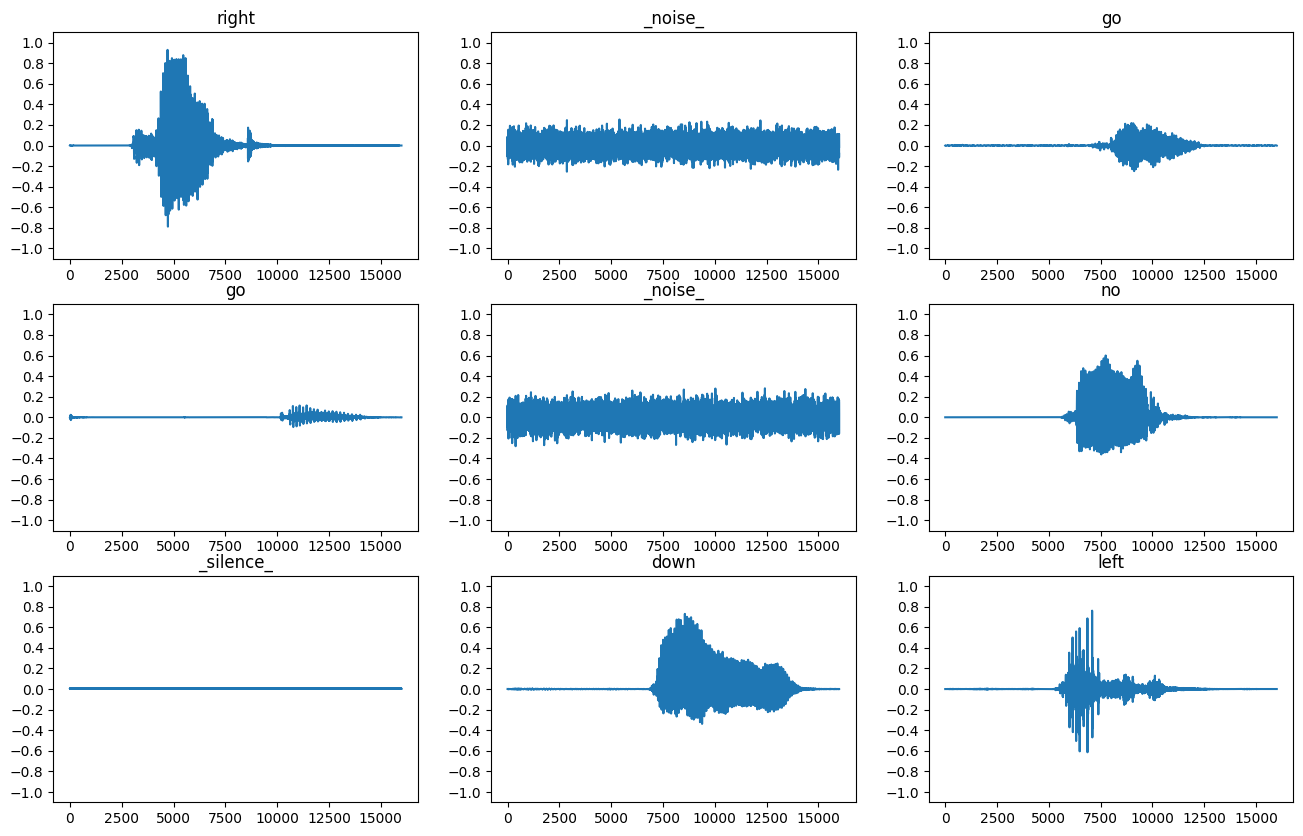

In [31]:
plt.figure(figsize=(16, 10))
rows = 3
cols = 3
n = rows * cols
for i in range(n):
  plt.subplot(rows, cols, i+1)
  audio_signal = example_audio[i]
  plt.plot(audio_signal)
  plt.title(label_names[example_labels[i]])
  plt.yticks(np.arange(-1.2, 1.2, 0.2))
  plt.ylim([-1.1, 1.1])

## Convert waveforms to spectrograms

The waveforms in the dataset are represented in the time domain. Next, you'll transform the waveforms from the time-domain signals into the time-frequency-domain signals by computing the [short-time Fourier transform (STFT)](https://en.wikipedia.org/wiki/Short-time_Fourier_transform) to convert the waveforms to as [spectrograms](https://en.wikipedia.org/wiki/Spectrogram), which show frequency changes over time and can be represented as 2D images. You will feed the spectrogram images into your neural network to train the model.

A Fourier transform (`tf.signal.fft`) converts a signal to its component frequencies, but loses all time information. In comparison, STFT (`tf.signal.stft`) splits the signal into windows of time and runs a Fourier transform on each window, preserving some time information, and returning a 2D tensor that you can run standard convolutions on.

Create a utility function for converting waveforms to spectrograms:

- The waveforms need to be of the same length, so that when you convert them to spectrograms, the results have similar dimensions. This can be done by simply zero-padding the audio clips that are shorter than one second (using `tf.zeros`).
- When calling `tf.signal.stft`, choose the `frame_length` and `frame_step` parameters such that the generated spectrogram "image" is almost square. For more information on the STFT parameters choice, refer to [this Coursera video](https://www.coursera.org/lecture/audio-signal-processing/stft-2-tjEQe) on audio signal processing and STFT.
- The STFT produces an array of complex numbers representing magnitude and phase. However, in this tutorial you'll only use the magnitude, which you can derive by applying `tf.abs` on the output of `tf.signal.stft`.

### Microspeech-Compatible Spectrogram (30ms window)

Microspeech uses a **30ms window** at 16kHz = **480 samples** per frame.
We align STFT parameters to match exactly:
- `frame_length=480` (30ms)
- `frame_step=160` (10ms hop, standard microspeech stride)
- Log-mel filterbank with 40 bins (matches TFLite Micro AudioPreprocessor)

Training and inference **must use the same preprocessing** — this was the root cause of wrong detections.

In [32]:
# =========================
# Constants
# =========================
SAMPLE_RATE               = 16000
FRAME_LENGTH_MS           = 30
FRAME_STEP_MS             = 20
FRAME_LENGTH              = int(SAMPLE_RATE * FRAME_LENGTH_MS / 1000)   # 480
FRAME_STEP                = int(SAMPLE_RATE * FRAME_STEP_MS  / 1000)    # 320
FFT_LENGTH                = 512
NUM_MEL_BINS              = 40
LOWER_FREQ_HZ             = 125.0
UPPER_FREQ_HZ             = 7500.0
WINDOW_SCALING_BITS       = 12
FILTER_BANK_SCALING_BITS  = 8
FILTER_BANK_POST_SCALING_BITS = 6
PCAN_STRENGTH             = 0.95
PCAN_OFFSET               = 80.0
PCAN_GAIN_BITS            = 21
EVEN_SMOOTHING            = 0.025
ODD_SMOOTHING             = 0.06
MIN_SIGNAL_REMAINING      = 0.05
LEGACY_OUTPUT_SCALING     = 25.6
VALUE_SCALE               = 256
VALUE_DIV                 = int((25.6 * 26.0) + 0.5)                    # 666
INT8_OFFSET               = -128
# Derived constants
NUM_SPEC_BINS   = FFT_LENGTH // 2 + 1                                    # 257
FFT_SIZE_LOG2   = int(math.log2(FFT_LENGTH))                             # 9
CORRECTION_BITS = FFT_SIZE_LOG2 - int(FILTER_BANK_SCALING_BITS / 2)     # 5
ENERGY_START    = max(1, int(LOWER_FREQ_HZ * FFT_LENGTH / SAMPLE_RATE)) # 4
ENERGY_END      = min(NUM_SPEC_BINS,
                      int(UPPER_FREQ_HZ * FFT_LENGTH / SAMPLE_RATE) + 1)# 241
TIME_STEPS       = math.floor((SAMPLE_RATE - FRAME_LENGTH) / FRAME_STEP) + 1

In [86]:

# =========================
# Mel Matrix
# =========================
def build_mel_matrix():
    return tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=NUM_MEL_BINS,
        num_spectrogram_bins=NUM_SPEC_BINS,
        sample_rate=SAMPLE_RATE,
        lower_edge_hertz=LOWER_FREQ_HZ,
        upper_edge_hertz=UPPER_FREQ_HZ,
    )

MEL_MATRIX = build_mel_matrix()                                          # (257, 40) float32

# =========================
# Step 2: Hann Window
# =========================
def apply_hann_window(audio_frame):
    """
    Input:  (1, 480) float32
    Output: (1, 480) float32
    """
    hann        = tf.signal.hann_window(FRAME_LENGTH, periodic=False, dtype=tf.float32)
    hann_scaled = hann * float(2 ** WINDOW_SCALING_BITS)
    return audio_frame * hann_scaled                                     # float32

# =========================
# Step 3-4: FftAutoScale
# =========================
def fft_auto_scale(windowed):
    """
    Input:  (1, 480) float32
    Output: (480,) float32, scalar float32
    All float32 — no int32 cast
    """
    windowed    = tf.reshape(windowed, [-1])                             # (480,) float32
    max_val     = tf.reduce_max(tf.abs(windowed)) + 1e-9
    scale_shift = tf.math.floor(
        tf.math.log(float(2 ** WINDOW_SCALING_BITS) / max_val)
        / tf.math.log(2.0)
    )
    scale_shift = tf.maximum(scale_shift, 0.0)                          # float32, no cast
    scaled      = windowed * tf.pow(2.0, scale_shift)
    return scaled, scale_shift                                           # float32, float32

# =========================
# Step 5: RFFT
# =========================
def compute_rfft(scaled_window):
    """
    Input:  (480,) float32
    Output: (257,) complex64
    """
    return tf.signal.rfft(scaled_window, fft_length=[FFT_LENGTH])

# =========================
# Step 6-7: SignalEnergy + zero-fill
# =========================
def compute_energy(fft_output):
    """
    Input:  (257,) complex64
    Output: (257,) float32
    All float32 — no uint32/int32 cast
    """
    energy       = (tf.square(tf.math.real(fft_output))
                  + tf.square(tf.math.imag(fft_output)))                 # float32
    zeros_head   = tf.zeros([ENERGY_START],               dtype=tf.float32)
    energy_slice = energy[ENERGY_START:ENERGY_END]
    zeros_tail   = tf.zeros([NUM_SPEC_BINS - ENERGY_END], dtype=tf.float32)
    return tf.concat([zeros_head, energy_slice, zeros_tail], axis=0)     # float32

# =========================
# Step 8: FilterBank → 40 channels
# =========================
def apply_filter_bank(energy):
    """
    Input:  (257,) float32  ← already float32, no cast needed
    Output: (40,)  float32
    """
    mel = tf.matmul(tf.expand_dims(energy, 0), MEL_MATRIX)              # (1, 40) float32
    return tf.squeeze(mel, axis=0)                                       # (40,) float32

# =========================
# Step 9: FilterBankSquareRoot
# =========================
def filter_bank_sqrt(mel, scale_shift):
    """
    Input:  (40,) float32, scalar float32
    Output: (40,) float32
    scale_shift is float32 — no cast needed
    """
    correction = tf.pow(2.0, 2.0 * scale_shift)                         # float32
    return tf.sqrt(tf.maximum(mel / correction, 0.0))                   # float32

# =========================
# Step 10: SpectralSubtraction
# =========================
def spectral_subtraction(mel):
    """
    Input:  (40,) float32
    Output: (40,) float32, (40,) float32
    """
    noise_estimate = tf.reduce_mean(mel, keepdims=True) * MIN_SIGNAL_REMAINING
    smoothing      = (EVEN_SMOOTHING + ODD_SMOOTHING) / 2.0
    mel_clean      = tf.maximum(mel - noise_estimate * smoothing, 0.0)
    return mel_clean, noise_estimate                                     # float32, float32

# =========================
# Step 11: PCAN Gain Control
# =========================
def pcan_gain_control(mel, noise_estimate):
    """
    Input:  (40,) float32, (40,) float32
    Output: (40,) float32
    """
    gain        = tf.pow(PCAN_OFFSET + noise_estimate, -PCAN_STRENGTH)
    gain_scaled = tf.round(gain * float(2 ** PCAN_GAIN_BITS))
    return mel * gain_scaled / float(2 ** PCAN_GAIN_BITS)               # float32

# =========================
# Step 12: FilterBankLog
# =========================
def filter_bank_log(agc_output):
    """
    Input:  (40,) float32
    Output: (40,) float32  ← no int16 cast
    """
    input_correction = float(2 ** CORRECTION_BITS)
    output_scale     = float(2 ** FILTER_BANK_POST_SCALING_BITS)
    corrected        = agc_output / input_correction
    log_val          = tf.math.log(tf.maximum(corrected, 1.0)) / tf.math.log(2.0)
    return log_val * output_scale                                        # float32

# =========================
# Step 13: Legacy int8
# =========================
def to_int8(log_scaled):
    """
    Input:  (40,) float32
    Output: (40,) int8
    Keep everything float32 until final clip+cast to int8
    """
    feature = tf.round(log_scaled)                                       # float32
    feature = (feature * float(VALUE_SCALE) + float(VALUE_DIV // 2)) / float(VALUE_DIV)
    feature = feature + INT8_OFFSET                                      # float32 (-128.0)
    feature = tf.clip_by_value(feature, -128.0, 127.0)                  # float32
    return tf.cast(feature, tf.int8)                                     # ← only cast at end

# =========================
# Full pipeline (core)
# =========================
def get_spectrogram(audio_frame, quantize=False):
    """
    Core pipeline.
    Args:
        audio_frame: (1, 480) float32  ← scaled to int16 range
        quantize:    True  → (40,) int8
                     False → (40,) float32
    All intermediate tensors stay float32
    """
    windowed                    = apply_hann_window(audio_frame)
    scaled_window, scale_shift  = fft_auto_scale(windowed)
    fft_output                  = compute_rfft(scaled_window)
    energy                      = compute_energy(fft_output)
    mel                         = apply_filter_bank(energy)
    mel                         = filter_bank_sqrt(mel, scale_shift)
    mel, noise_estimate         = spectral_subtraction(mel)
    mel                         = pcan_gain_control(mel, noise_estimate)
    log_scaled                  = filter_bank_log(mel)

    if quantize:
        return to_int8(log_scaled)                                       # (40,) int8
    else:
        return log_scaled / LEGACY_OUTPUT_SCALING                        # (40,) float32

# =========================
# Wrapper: int16 MCU input
# =========================
def get_spectrogram_from_int(audio_frame, quantize=False):
    """
    Args:
        audio_frame: (1, 480) int16 ← raw PCM from ADC/mic
    """
    if len(audio_frame.shape) == 1:
        audio_frame = tf.expand_dims(audio_frame, axis=0)
    audio = tf.cast(audio_frame, tf.float32)
    return get_spectrogram(audio, quantize)

## Training preprocessing audio log mel spectrogram

In [90]:
def waveform_to_spectrogram(waveform, quantize=False):
    """
    Args:
        waveform: (16000,) or (batch, 16000) float32 [-1.0, 1.0]
    Returns:
        (TIME_STEPS, 40) or (batch, TIME_STEPS, 40)
    """
    # ── handle both batched and unbatched ──
    if len(waveform.shape) == 1:
        return _process_single(waveform, quantize)
    else:
        return tf.map_fn(
            fn=lambda w: _process_single(w, quantize),
            elems=waveform,
            fn_output_signature=tf.float32 if not quantize else tf.int8
        )

def _process_single(waveform, quantize=False):
    """
    Args:
        waveform: (16000,) float32 [-1.0, 1.0]
    Returns:
        (TIME_STEPS, 40)
    """
    # ── pad/trim to 16000 ──
    target_len  = SAMPLE_RATE                                    # 16000
    current_len = tf.shape(waveform)[0]
    pad_len     = tf.maximum(0, target_len - current_len)
    waveform    = tf.concat(
        [waveform, tf.zeros([pad_len], dtype=tf.float32)],
        axis=0
    )
    waveform    = waveform[:target_len]                          # (16000,)

    # ── scale [-1,1] → int16 range ──
    waveform = tf.cast(
        tf.cast(waveform * 32767.0, tf.int16),
        tf.float32
    )

    # ── slice into frames ──
    frames = tf.signal.frame(
        waveform,
        frame_length=FRAME_LENGTH,                               # 480
        frame_step=FRAME_STEP                                    # 320
    )                                                            # (TIME_STEPS, 480)

    # ── process each frame ──
    specs = tf.map_fn(
        fn=lambda frame: get_spectrogram(
            tf.reshape(frame, [1, FRAME_LENGTH]),                # (1, 480)
            quantize=quantize
        ),
        elems=frames,
        fn_output_signature=tf.float32 if not quantize else tf.int8
    )                                                            # (TIME_STEPS, 40)

    return specs

In [89]:
# =========================
# TF Module
# =========================
from ai_edge_litert.interpreter import Interpreter
class AudioPreprocessorModule(tf.Module):
    def __init__(self):
        super().__init__()

    @tf.function(input_signature=[
        tf.TensorSpec(shape=[1, FRAME_LENGTH], dtype=tf.float32, name='audio_frame')
    ])
    def generate_feature(self, audio_frame):
        return get_spectrogram(audio_frame, quantize=True)

    @tf.function(input_signature=[
        tf.TensorSpec(shape=[1, FRAME_LENGTH], dtype=tf.float32, name='audio_frame')
    ])
    def generate_feature_float(self, audio_frame):
        return get_spectrogram(audio_frame, quantize=False)

# =========================
# Export TFLite
# =========================
def export_tflite(quantize=True, dataset=None):
    module = AudioPreprocessorModule()

    if quantize:
        cf       = module.generate_feature.get_concrete_function()
        out_path = 'audio_preprocessor_int8.tflite'
    else:
        cf       = module.generate_feature_float.get_concrete_function()
        out_path = 'audio_preprocessor_float32.tflite'

    converter = tf.lite.TFLiteConverter.from_concrete_functions([cf], module)

    if quantize:
        converter.optimizations             = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

        def representative_dataset():
            if dataset is not None:
                count = 0
                max_samples = 200                                    # ← hard limit
                for waveform, _ in dataset:
                    for i in range(waveform.shape[0]):
                        if count >= max_samples:
                            return                                   # ← stop immediately
                        clip  = waveform[i]                         # (16000,) float32 [-1,1]
                        # just use first frame per clip, no inner loop
                        frame = clip[:FRAME_LENGTH]                 # (480,) float32
                        frame = tf.reshape(frame, [1, FRAME_LENGTH])
                        # scale [-1,1] → int16 range
                        frame = tf.cast(
                            tf.cast(frame * 32767.0, tf.int16),
                            tf.float32
                        )
                        yield [frame]
                        count += 1
            else:
                for _ in range(200):
                    sample = np.random.randint(
                        -32768, 32767,
                        size=(1, FRAME_LENGTH),
                        dtype=np.int16
                    ).astype(np.float32)
                    yield [sample]

        converter.representative_dataset = representative_dataset

    tflite_model = converter.convert()
    with open(out_path, 'wb') as f:
        f.write(tflite_model)
    print(f'Saved → {out_path}  ({len(tflite_model):,} bytes)')
    return out_path

# =========================
# Verify TFLite
# =========================
def verify_tflite(path):
    interpreter = Interpreter(model_path=path)
    interpreter.allocate_tensors()
    inp = interpreter.get_input_details()[0]
    out = interpreter.get_output_details()[0]

    print(f'\n--- {path} ---')
    print(f'Input  shape={inp["shape"]}  dtype={inp["dtype"]}')
    print(f'Output shape={out["shape"]}  dtype={out["dtype"]}')

    dummy = np.random.randint(
        -32768, 32767,
        size=(1, FRAME_LENGTH),
        dtype=np.int16
    ).astype(np.float32)
    interpreter.set_tensor(inp['index'], dummy)
    interpreter.invoke()
    result = interpreter.get_tensor(out['index'])
    print(f'Output values: {result}')
    print(f'Min={result.min()}  Max={result.max()}')

# Export + verify int8
path_int8 = export_tflite(quantize=True,dataset=train_ds)
verify_tflite(path_int8)
# Export + verify float32
path_float = export_tflite(quantize=False,dataset=train_ds)
verify_tflite(path_float)

INFO:tensorflow:Assets written to: /tmp/tmp00gyua52/assets


INFO:tensorflow:Assets written to: /tmp/tmp00gyua52/assets
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32


Saved → audio_preprocessor_int8.tflite  (24,480 bytes)

--- audio_preprocessor_int8.tflite ---
Input  shape=[  1 480]  dtype=<class 'numpy.float32'>
Output shape=[40]  dtype=<class 'numpy.int8'>
Output values: [-127 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127
 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127
 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127]
Min=-127  Max=-127
INFO:tensorflow:Assets written to: /tmp/tmp8w85sa6w/assets


INFO:tensorflow:Assets written to: /tmp/tmp8w85sa6w/assets


Saved → audio_preprocessor_float32.tflite  (51,040 bytes)

--- audio_preprocessor_float32.tflite ---
Input  shape=[  1 480]  dtype=<class 'numpy.float32'>
Output shape=[40]  dtype=<class 'numpy.float32'>
Output values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Min=0.0  Max=0.0


Next, start exploring the data. Print the shapes of one example's tensorized waveform and the corresponding spectrogram, and play the original audio:

In [91]:
for i in range(3):
  label = label_names[example_labels[i]]
  waveform = example_audio[i]
  print(waveform)
  spectrogram = waveform_to_spectrogram(waveform)

  print('Label:', label)
  print('Waveform shape:', waveform.shape)
  print('Spectrogram shape:', spectrogram.shape)
  print('Audio playback')
  display.display(display.Audio(waveform, rate=16000))

tf.Tensor(
[-1.2207031e-04 -3.0517578e-04 -3.6621094e-04 ...  3.9672852e-04
  2.4414062e-04 -9.1552734e-05], shape=(16000,), dtype=float32)
Label: right
Waveform shape: (16000,)
Spectrogram shape: (49, 40)
Audio playback


tf.Tensor(
[ 0.02572632  0.0088501  -0.06143188 ... -0.11553955 -0.00210571
 -0.08044434], shape=(16000,), dtype=float32)
Label: _noise_
Waveform shape: (16000,)
Spectrogram shape: (49, 40)
Audio playback


tf.Tensor(
[-0.00088501 -0.00119019 -0.00158691 ... -0.00085449 -0.0010376
 -0.0010376 ], shape=(16000,), dtype=float32)
Label: go
Waveform shape: (16000,)
Spectrogram shape: (49, 40)
Audio playback


Now, define a function for displaying a spectrogram:

In [192]:
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
  # Convert the frequencies to log scale and transpose, so that the time is
  # represented on the x-axis (columns).
  # Add an epsilon to avoid taking a log of zero.
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)

Plot the example's waveform over time and the corresponding spectrogram (frequencies over time):

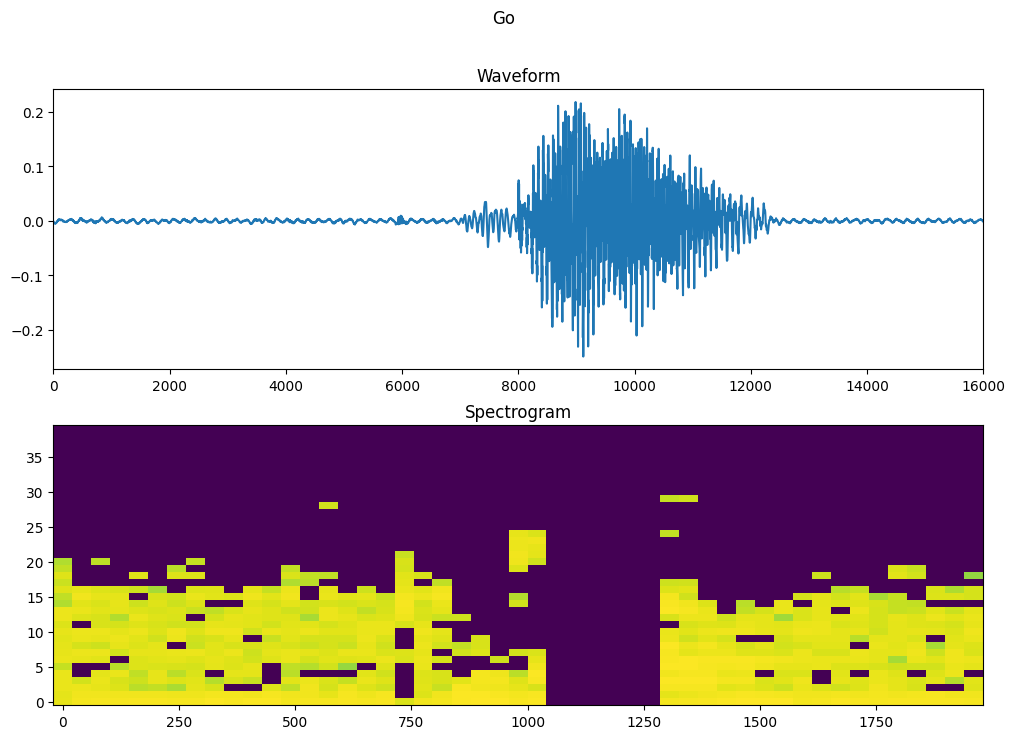

In [193]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 16000])

plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.suptitle(label.title())
plt.show()

Now, create spectrogram datasets from the audio datasets:

In [362]:
def augment_waveform(waveform, label):
    """
    Safe minimal augmentation.
    Args:
        waveform: (16000,) float32 [-1.0, 1.0]
    Returns:
        (16000,) float32 [-1.0, 1.0]
    """
    # ── 1. gentle volume scaling ──
    gain     = tf.random.uniform([], 0.9, 1.1)                  # ← very mild
    waveform = waveform * gain
    waveform = tf.clip_by_value(waveform, -1.0, 1.0)

    # ── 2. very subtle noise ──
    noise_std = tf.random.uniform([], 0.0, 0.002)               # ← very subtle
    noise     = tf.random.normal(tf.shape(waveform), stddev=noise_std)
    waveform  = waveform + noise
    waveform  = tf.clip_by_value(waveform, -1.0, 1.0)

    # ── 3. mild time shift ──
    shift    = tf.random.uniform([], -400, 400, dtype=tf.int32) # ← ±0.025s only
    waveform = tf.roll(waveform, shift, axis=0)

    return waveform, label                                       # ← no speed perturbation


In [363]:
BATCH_SIZE = 64
def make_spec_ds(ds, training=False):
    ds = ds.unbatch()

    if training:
        ds = ds.map(augment_waveform, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.map(
        lambda audio, label: (waveform_to_spectrogram(audio), label),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    ds = ds.cache()

    if training:
        ds = ds.shuffle(10000)

    ds = ds.batch(BATCH_SIZE, drop_remainder=True)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [364]:
train_spectrogram_ds = make_spec_ds(train_ds, training=True)
val_spectrogram_ds = make_spec_ds(val_ds)
test_spectrogram_ds = make_spec_ds(test_ds)

Examine the spectrograms for different examples of the dataset:

In [365]:
for example_spectrograms, example_spect_labels in train_spectrogram_ds.take(1):
  break

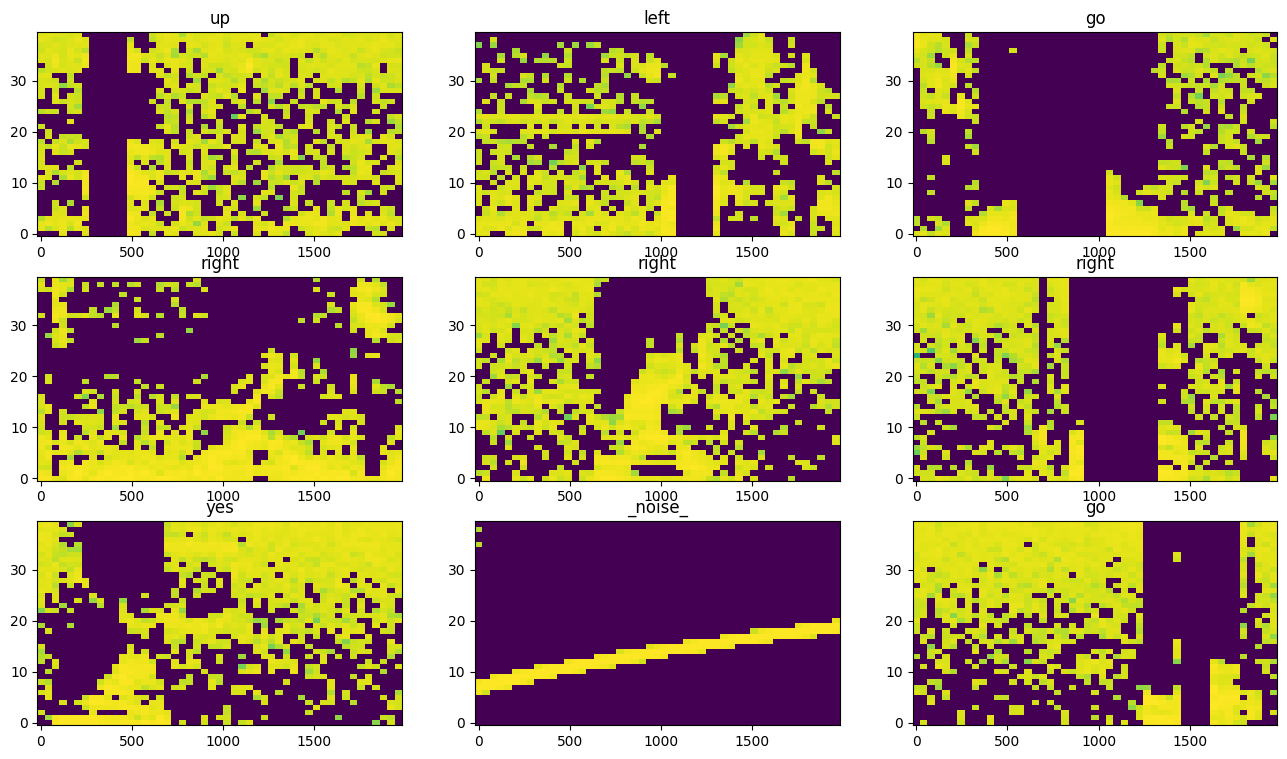

In [366]:
rows = 3
cols = 3
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))

for i in range(n):
    r = i // cols
    c = i % cols
    ax = axes[r][c]
    plot_spectrogram(example_spectrograms[i].numpy(), ax)
    ax.set_title(label_names[example_spect_labels[i].numpy()])

plt.show()

## Build and train the model

Add `Dataset.cache` and `Dataset.prefetch` operations to reduce read latency while training the model:

In [367]:
train_spectrogram_ds = train_spectrogram_ds.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)
test_spectrogram_ds = test_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)

For the model, you'll use a simple convolutional neural network (CNN), since you have transformed the audio files into spectrogram images.

Your `tf.keras.Sequential` model will use the following Keras preprocessing layers:

- `tf.keras.layers.Resizing`: to downsample the input to enable the model to train faster.
- `tf.keras.layers.Normalization`: to normalize each pixel in the image based on its mean and standard deviation.

For the `Normalization` layer, its `adapt` method would first need to be called on the training data in order to compute aggregate statistics (that is, the mean and the standard deviation).

In [368]:
input_shape = example_spectrograms.shape[1:]
print('Input shape:', input_shape)   # (49, 40)

num_labels = len(label_names)
print(f'Labels ({num_labels}):', label_names)

# ── adapt norm_layer on (49, 40, 1) data ──
norm_layer = layers.Normalization()
norm_layer.adapt(
    data=train_spectrogram_ds.map(
        lambda spec, label: tf.expand_dims(spec, axis=-1)  # ← (49, 40, 1)
    )
)

model = models.Sequential([
    layers.Input(shape=input_shape),                             # (49, 40)
    layers.Reshape((input_shape[0], input_shape[1], 1)),         # (49, 40, 1)
    norm_layer,

    # ── Block 1 ──
    layers.Conv2D(16, (3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),                                  # (24, 20, 16)
    layers.Dropout(0.1),

    # ── Block 2 ──
    layers.Conv2D(32, (3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),                                  # (12, 10, 32)
    layers.Dropout(0.1),

    # ── Block 3 ──
    layers.Conv2D(64, (3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),                                  # (6, 5, 64)
    layers.Dropout(0.2),

    # ── Block 4 ──
    layers.Conv2D(64, (3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.GlobalAveragePooling2D(),                              # (64,)
    layers.Dropout(0.2),

    # ── Classifier ──
    layers.Dense(num_labels),                                     # ← no hidden dense
], name='microspeech_mcu')


model.summary()

Input shape: (49, 40)
Labels (10): ['_noise_' '_silence_' 'down' 'go' 'left' 'no' 'right' 'stop' 'up' 'yes']


Model: "microspeech_mcu"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_23 (Reshape)            │ (None, 49, 40, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_31                │ (None, 49, 40, 1)      │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 49, 40, 16)     │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (None, 49, 40, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_51 (Activation)      │ (None, 49, 40, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (None, 24, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 24, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 24, 20, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_67          │ (None, 24, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_52 (Activation)      │ (None, 24, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_58 (MaxPooling2D) │ (None, 12, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ (None, 12, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 12, 10, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_68          │ (None, 12, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_53 (Activation)      │ (None, 12, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_59 (MaxPooling2D) │ (None, 6, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ (None, 6, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ (None, 6, 5, 64)       │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_69          │ (None, 6, 5, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_54 (Activation)      │ (None, 6, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_13     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 64)             │             

 Total params: 61,405 (239.87 KB)

 Trainable params: 61,050 (238.48 KB)

 Non-trainable params: 355 (1.39 KB)

Configure the Keras model with the Adam optimizer and the cross-entropy loss:

In [369]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)


Train the model over 10 epochs for demonstration purposes:

In [370]:
EPOCHS = 200

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        verbose=1,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        verbose=1,
        min_lr=1e-5
    ),
]
history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)


Epoch 1/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.3522 - loss: 1.8985 - val_accuracy: 0.3774 - val_loss: 1.9544 - learning_rate: 0.0010
Epoch 2/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5371 - loss: 1.4322 - val_accuracy: 0.3954 - val_loss: 1.7752 - learning_rate: 0.0010
Epoch 3/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6228 - loss: 1.1911 - val_accuracy: 0.5240 - val_loss: 1.3505 - learning_rate: 0.0010
Epoch 4/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6600 - loss: 1.0355 - val_accuracy: 0.6839 - val_loss: 1.0240 - learning_rate: 0.0010
Epoch 5/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6986 - loss: 0.9321 - val_accuracy: 0.6478 - val_loss: 1.0186 - learning_rate: 0.0010
Epoch 6/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7223 - loss: 0.8677 - val_accuracy: 0.6863 - val_loss: 0.9622 - learning_rate: 0.0010
Epoch 7/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7310 - loss: 

Let's plot the training and validation loss curves to check how your model has improved during training:

Text(0, 0.5, 'Accuracy [%]')

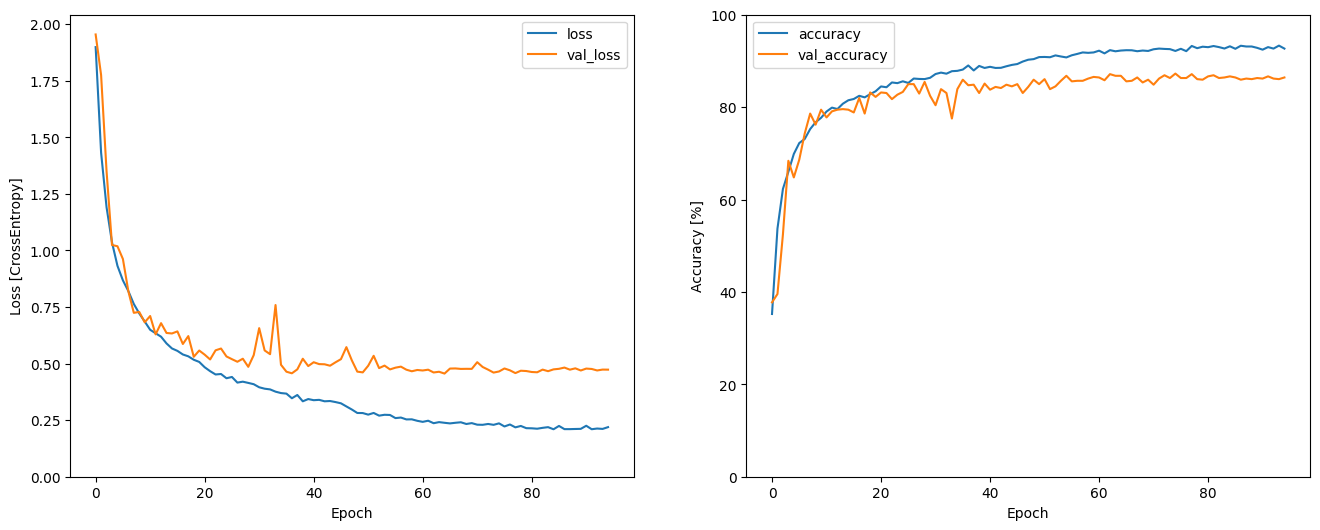

In [371]:
metrics = history.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [CrossEntropy]')

plt.subplot(1,2,2)
plt.plot(history.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')

## Evaluate the model performance

Run the model on the test set and check the model's performance:

In [372]:
model.evaluate(test_spectrogram_ds, return_dict=True)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.8425 - loss: 0.5750


{'accuracy': 0.8425480723381042, 'loss': 0.5749671459197998}

## Confidence-Threshold Inference

After training, run inference with a confidence threshold. Predictions below the threshold are flagged as uncertain (could be noise or silence).

In [428]:
CONFIDENCE_THRESHOLD = 0.6

def run_inference_with_threshold(file_path, model, label_names,
                                  threshold=CONFIDENCE_THRESHOLD):
    """
    Infer from a WAV file of ANY length.
    Short clips are zero-padded to 1 second before inference.
    """
    x = tf.io.read_file(str(file_path))
    x, sr = tf.audio.decode_wav(x, desired_channels=1)
    x = tf.squeeze(x, axis=-1)                          # (N,) float32 [-1,1]
    waveform = x

    # ── waveform_to_spectrogram handles pad/trim + framing internally ──
    spec = waveform_to_spectrogram(x, quantize=False)   # (TIME_STEPS, 40)
    spec = tf.expand_dims(spec, axis=-1)                # (TIME_STEPS, 40, 1)
    spec = spec[tf.newaxis, ...]                        # (1, TIME_STEPS, 40, 1)

    logits = model(spec, training=False)
    probs  = tf.nn.softmax(logits[0]).numpy()
    conf   = float(np.max(probs))
    cid    = int(np.argmax(probs))
    label  = label_names[cid]

    if conf >= threshold:
        result = f"✅ {label}  ({conf:.1%} confidence)"
    else:
        result = (f"❓ Low confidence — best guess: '{label}' "
                  f"at {conf:.1%}  (threshold={threshold:.0%})")

    return result, waveform, conf, label


# ── Demo on test batch ──
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD:.0%}\n")
n_above = n_below = 0

for spec_batch, label_batch in test_spectrogram_ds.take(1):
    # spec_batch shape: (batch, TIME_STEPS, 40)
    for idx in range(min(20, len(label_batch))):
        true_label = label_names[label_batch[idx].numpy()]

        spec = spec_batch[idx]                          # (TIME_STEPS, 40)
        spec = tf.expand_dims(spec, axis=-1)            # (TIME_STEPS, 40, 1)
        spec = spec[tf.newaxis, ...]                    # (1, TIME_STEPS, 40, 1)

        logits = model(spec, training=False)
        probs  = tf.nn.softmax(logits[0]).numpy()
        conf   = float(np.max(probs))
        pred   = label_names[int(np.argmax(probs))]
        flag   = "✅" if conf >= CONFIDENCE_THRESHOLD else "❓"

        print(f"  True: {true_label:<12}  Pred: {pred:<12}  Conf: {conf:.1%}  {flag}")
        n_above += (1 if conf >= CONFIDENCE_THRESHOLD else 0)
        n_below += (0 if conf >= CONFIDENCE_THRESHOLD else 1)

print(f"\nAbove threshold: {n_above}  |  Below threshold: {n_below}")
# ── Single file demo ──
sample_file = data_dir / 'no/01bb6a2a_nohash_0.wav'
result_text, audio_data, conf, pred = run_inference_with_threshold(
    sample_file, model, label_names)
print(f"\nSingle-file result: {result_text}")
display.display(display.Audio(audio_data, rate=16000))

Confidence threshold: 60%

  True: left          Pred: left          Conf: 99.8%  ✅
  True: down          Pred: down          Conf: 99.9%  ✅
  True: stop          Pred: stop          Conf: 83.8%  ✅
  True: _noise_       Pred: _noise_       Conf: 99.9%  ✅
  True: up            Pred: up            Conf: 99.6%  ✅
  True: no            Pred: no            Conf: 38.4%  ❓
  True: yes           Pred: yes           Conf: 100.0%  ✅
  True: down          Pred: down          Conf: 77.8%  ✅
  True: yes           Pred: yes           Conf: 99.7%  ✅
  True: up            Pred: up            Conf: 98.6%  ✅
  True: left          Pred: left          Conf: 99.8%  ✅
  True: down          Pred: down          Conf: 99.6%  ✅
  True: no            Pred: no            Conf: 80.4%  ✅
  True: no            Pred: no            Conf: 99.9%  ✅
  True: yes           Pred: yes           Conf: 98.5%  ✅
  True: yes           Pred: yes           Conf: 99.9%  ✅
  True: no            Pred: no            Conf: 64.4%  ✅
  T

### Display a confusion matrix

Use a [confusion matrix](https://developers.google.com/machine-learning/glossary#confusion-matrix) to check how well the model did classifying each of the commands in the test set:


In [429]:
y_pred = model.predict(test_spectrogram_ds)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [430]:
y_pred = tf.argmax(y_pred, axis=1)

In [431]:
y_true = tf.concat(list(test_spectrogram_ds.map(lambda s,lab: lab)), axis=0)

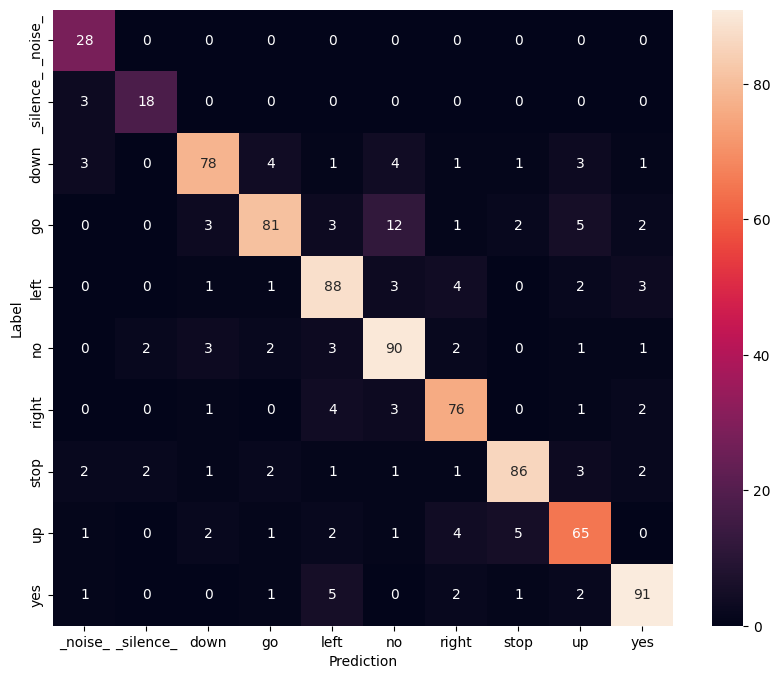

In [432]:
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

## Run inference on an audio file

Finally, verify the model's prediction output using an input audio file of someone saying "no". How well does your model perform?

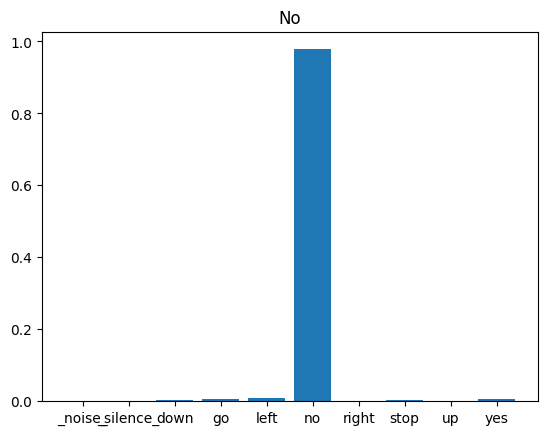

In [433]:
x = data_dir/'no/01bb6a2a_nohash_0.wav'
x = tf.io.read_file(str(x))
x, sample_rate = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000,)
x = tf.squeeze(x, axis=-1)
waveform = x
x = waveform_to_spectrogram(x)
x = x[tf.newaxis,...]

prediction = model(x)
x_labels = label_names
plt.bar(x_labels, tf.nn.softmax(prediction[0]))
plt.title('No')
plt.show()

display.display(display.Audio(waveform, rate=16000))

As the output suggests, your model should have recognized the audio command as "no".

## Export the model with preprocessing

The model's not very easy to use if you have to apply those preprocessing steps before passing data to the model for inference. So build an end-to-end version:

In [475]:
class ExportModel(tf.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    @tf.function(input_signature=[
        tf.TensorSpec(
            shape=[TIME_STEPS, NUM_MEL_BINS],                    # ← (49, 40) no batch
            dtype=tf.float32,
            name='spectrogram'
        )
    ])
    def __call__(self, x):
        x      = tf.expand_dims(x, axis=0)                       # (49,40) → (1,49,40)
        logits = self.model(x, training=False)                   # (1, num_labels)
        probs  = tf.nn.softmax(logits)                           # (1, num_labels)
        return tf.squeeze(probs, axis=0)                         # (num_labels,) ✅



In [476]:
def wav_to_spectrogram(file_path):
    audio_binary = tf.io.read_file(file_path)
    waveform, _  = tf.audio.decode_wav(
        audio_binary,
        desired_channels=1,
        desired_samples=16000
    )
    waveform    = tf.squeeze(waveform, axis=-1)                  # (16000,)
    spectrogram = waveform_to_spectrogram(waveform)              # (49, 40)
    return spectrogram                                           # (1, 49, 40)

def wav_to_waveform(file_path):
    audio_binary = tf.io.read_file(file_path)
    waveform, _  = tf.audio.decode_wav(
        audio_binary,
        desired_channels=1,
        desired_samples=16000
    )
    waveform    = tf.squeeze(waveform, axis=-1)                  # (16000,)
    return waveform

In [479]:
DEFAULT_THRESHOLD = 0.8

def predict_with_threshold(model, spectrogram, label_names,
                            threshold=DEFAULT_THRESHOLD):
    """
    Run inference and apply confidence threshold.
    Args:
        model:       TensorFlow model or imported SavedModel
        spectrogram: (49, 40) or (1, 49, 40) float32
        label_names: list of class names
        threshold:   detection threshold
    Returns:
        dict with prediction results
    """
    # ── ensure (49, 40) — no batch ──
    if hasattr(spectrogram, 'numpy'):
        spectrogram = spectrogram.numpy()
    spectrogram = np.squeeze(spectrogram)                        # (49, 40)
    spectrogram = tf.constant(spectrogram, dtype=tf.float32)    # back to tensor

    probs = model(spectrogram)                                   # (num_labels,)

    if hasattr(probs, 'numpy'):
        probs = probs.numpy()

    probs      = probs.flatten()                                 # ensure 1D
    best_index = int(np.argmax(probs))
    best_score = float(probs[best_index])                        # ← 1D index

    return {
        'detected'    : best_score > threshold,
        'class_index' : best_index,
        'confidence'  : best_score,
        'class_name'  : str(label_names[best_index]) if best_score > threshold else None,
    }

Test run the "export" model:

In [480]:
spectrogram = wav_to_spectrogram(str(data_dir / "no/01bb6a2a_nohash_0.wav"))
print('Spectrogram shape:', spectrogram.shape)
export = ExportModel(model)
tf.saved_model.save(export, "saved",)
print(label_names)
predict_with_threshold(export, spectrogram, label_names)

Spectrogram shape: (49, 40)
INFO:tensorflow:Assets written to: saved/assets


INFO:tensorflow:Assets written to: saved/assets


['_noise_' '_silence_' 'down' 'go' 'left' 'no' 'right' 'stop' 'up' 'yes']


{'detected': True,
 'class_index': 5,
 'confidence': 0.9780339598655701,
 'class_name': 'no'}

Save and reload the model, the reloaded model gives identical output:

In [481]:
spectrogram = wav_to_spectrogram(str(data_dir / "yes/004ae714_nohash_0.wav"))
print('Spectrogram shape:', spectrogram.shape)
imported = tf.saved_model.load("saved")
predict_with_threshold(imported, spectrogram, label_names)

Spectrogram shape: (49, 40)


{'detected': True,
 'class_index': 9,
 'confidence': 0.9931221604347229,
 'class_name': 'yes'}

In [482]:
import tensorflow as tf
import numpy as np
import os
def generate_int8_tflite(model, dataset, output_path='keyword_model_int8.tflite'):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)  # ← from keras directly

    def representative_dataset():
        count = 0
        for spectrogram, _ in dataset:
            for i in range(spectrogram.shape[0]):
                if count >= 200:
                    return
                spec = spectrogram[i:i+1]                        # (1, 49, 40)
                spec = tf.cast(spec, tf.float32)
                yield [spec]
                count += 1

    converter.optimizations             = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset    = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    # ← float32 input, int8 output
    converter.inference_output_type     = tf.int8

    tflite_model = converter.convert()
    with open(output_path, 'wb') as f:
        f.write(tflite_model)

    print(f'Saved → {output_path}  ({len(tflite_model)/1024:.1f} KB)')
    return tflite_model


tflite_model = generate_int8_tflite(model, test_spectrogram_ds)


INFO:tensorflow:Assets written to: /tmp/tmpo0tin8g9/assets


INFO:tensorflow:Assets written to: /tmp/tmpo0tin8g9/assets


Saved artifact at '/tmp/tmpo0tin8g9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 49, 40), dtype=tf.float32, name='keras_tensor_434')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135464759011344: TensorSpec(shape=(1, 1, 1, 1), dtype=tf.float32, name=None)
  135464759010768: TensorSpec(shape=(1, 1, 1, 1), dtype=tf.float32, name=None)
  135464759010384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135464759014032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135464759015760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135464759015376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135464759013456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135464759012496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135464759013072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135464759013648: TensorSpec(shape=(), dtype=tf.resource, name=None

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved → keyword_model_int8.tflite  (71.9 KB)


fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: INT8


In [483]:

# =========================
# 3. Fix predict_tflite
# =========================
def predict_tflite(interpreter, spectrogram, label_names, threshold=0.6):
    input_details  = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # ── convert to numpy ──
    if hasattr(spectrogram, 'numpy'):
        spectrogram = spectrogram.numpy()

    # ── ensure float32 (1, 49, 40) ──
    spectrogram = spectrogram.astype(np.float32)
    spectrogram = spectrogram.reshape(input_details[0]['shape']) # force correct shape

    # ── float32 input — no quantization needed ──
    interpreter.set_tensor(input_details[0]['index'], spectrogram)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]['index'])

    # ── dequantize int8 output ──
    if output_details[0]['dtype'] == np.int8:
        scale, zero = output_details[0]['quantization']
        probs = (output.astype(np.float32) - zero) * scale
    else:
        probs = output.astype(np.float32)

    probs      = probs.flatten()
    probs      = np.exp(probs) / np.sum(np.exp(probs))          # softmax
    class_id   = int(np.argmax(probs))
    confidence = float(probs[class_id])

    return {
        'detected'   : confidence > threshold,
        'class_id'   : class_id,
        'class_name' : str(label_names[class_id]) if confidence > threshold else None,
        'confidence' : confidence,
    }


In [484]:
from ai_edge_litert.interpreter import Interpreter
interpreter_pre = Interpreter(model_path='audio_preprocessor_float32.tflite')
interpreter_pre.allocate_tensors()

input_details_pre  = interpreter_pre.get_input_details()
output_details_pre = interpreter_pre.get_output_details()

print('Input  shape:', input_details_pre[0]['shape'])                # (1, 49, 40)
print('Input  dtype:', input_details_pre[0]['dtype'])                # float32
print('Output shape:', output_details_pre[0]['shape'])               # (1, num_labels)
print('Output dtype:', output_details_pre[0]['dtype'])               # int8


Input  shape: [  1 480]
Input  dtype: <class 'numpy.float32'>
Output shape: [40]
Output dtype: <class 'numpy.float32'>


In [485]:
from ai_edge_litert.interpreter import Interpreter

interpreter = Interpreter(model_path='keyword_model_int8.tflite')
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('Input  shape:', input_details[0]['shape'])                # (1, 49, 40)
print('Input  dtype:', input_details[0]['dtype'])                # float32
print('Output shape:', output_details[0]['shape'])               # (1, num_labels)
print('Output dtype:', output_details[0]['dtype'])               # int8


Input  shape: [ 1 49 40]
Input  dtype: <class 'numpy.float32'>
Output shape: [ 1 10]
Output dtype: <class 'numpy.int8'>


In [509]:
def run_preprocessor(interpreter, waveform):
    """
    Args:
        waveform: (16000,) float32 [-1.0, 1.0]
    Returns:
        (TIME_STEPS, 40) float32
    """
    inp = interpreter.get_input_details()[0]
    out = interpreter.get_output_details()[0]

    # ── scale to int16 range ──
    waveform_int16 = tf.cast(
        tf.cast(waveform * 32767.0, tf.int16),
        tf.float32
    ).numpy()                                                    # (16000,)

    frames = []
    for start in range(0, 16000 - FRAME_LENGTH + 1, FRAME_STEP):
        frame = waveform_int16[start:start + FRAME_LENGTH]       # (480,)
        frame = frame.reshape(1, FRAME_LENGTH).astype(np.float32) # (1, 480) ✅

        interpreter.set_tensor(inp['index'], frame)
        interpreter.invoke()

        feat = interpreter.get_tensor(out['index'])              # (1, 40) float32
        frames.append(feat.flatten())                            # (40,)

    spectrogram = np.stack(frames, axis=0)                       # (TIME_STEPS, 40)
    return spectrogram                                           # (49, 40) ✅

In [510]:

# =========================
# 4. Test
# =========================
spectrogram = wav_to_spectrogram(str(data_dir / 'no/01bb6a2a_nohash_0.wav'))
print('Spectrogram shape:', spectrogram.shape)                   # (1, 49, 40)

result = predict_tflite(interpreter, spectrogram, label_names)
print(result)
spectrogram = wav_to_spectrogram(str(data_dir / "yes/004ae714_nohash_0.wav"))
print('Spectrogram shape:', spectrogram.shape)
result = predict_tflite(interpreter, spectrogram, label_names)
print(result)

Spectrogram shape: (49, 40)
{'detected': True, 'class_id': 5, 'class_name': 'no', 'confidence': 0.9801512956619263}
Spectrogram shape: (49, 40)
{'detected': True, 'class_id': 9, 'class_name': 'yes', 'confidence': 0.9939852952957153}


In [515]:

waveform = wav_to_waveform(str(data_dir / 'no/01bb6a2a_nohash_0.wav'))
spectogram = run_preprocessor(interpreter_pre, waveform)
result = predict_tflite(interpreter, spectogram, label_names)
print(result)

waveform = wav_to_waveform(str(data_dir / 'yes/004ae714_nohash_0.wav'))
spectogram = run_preprocessor(interpreter_pre, waveform)
result = predict_tflite(interpreter, spectogram, label_names)
print(result)


{'detected': True, 'class_id': 5, 'class_name': 'no', 'confidence': 0.9801512956619263}
{'detected': True, 'class_id': 9, 'class_name': 'yes', 'confidence': 0.9939852952957153}


In [516]:
# Install xxd if it is not available
MODEL_TFLITE = 'keyword_model_int8.tflite'
MODEL_TFLITE_MICRO  = 'keyword_model_int8.cc'
!apt-get update && apt-get -qq install xxd
# Convert to a C source file
!xxd -i {MODEL_TFLITE} > {MODEL_TFLITE_MICRO}
# Update variable names
REPLACE_TEXT = MODEL_TFLITE.replace('/', '_').replace('.', '_')
!sed -i 's/'{REPLACE_TEXT}'/g_model/g' {MODEL_TFLITE_MICRO}

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease     
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease                     
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease               
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does no

## Next steps

This tutorial demonstrated how to carry out simple audio classification/automatic speech recognition using a convolutional neural network with TensorFlow and Python. To learn more, consider the following resources:

- The [Sound classification with YAMNet](https://www.tensorflow.org/hub/tutorials/yamnet) tutorial shows how to use transfer learning for audio classification.
- The notebooks from [Kaggle's TensorFlow speech recognition challenge](https://www.kaggle.com/c/tensorflow-speech-recognition-challenge/overview).
- The
[TensorFlow.js - Audio recognition using transfer learning codelab](https://codelabs.developers.google.com/codelabs/tensorflowjs-audio-codelab/index.html#0) teaches how to build your own interactive web app for audio classification.
- [A tutorial on deep learning for music information retrieval](https://arxiv.org/abs/1709.04396) (Choi et al., 2017) on arXiv.
- TensorFlow also has additional support for [audio data preparation and augmentation](https://www.tensorflow.org/io/tutorials/audio) to help with your own audio-based projects.
- Consider using the [librosa](https://librosa.org/) library for music and audio analysis.

In [518]:
import zipfile
import os

zip_name = "dataset.zip"
base_dir = ""

files_to_zip = [
    "/kaggle/working/audio_preprocessor_float32.tflite",
    "/kaggle/working/audio_preprocessor_int8.tflite",
    "/kaggle/working/keyword_model_int8.cc",
    "/kaggle/working/keyword_model_int8.tflite",
    "/kaggle/working/saved/variables/variables.data-00000-of-00001",
    "/kaggle/working/saved/variables/variables.index",
    "/kaggle/working/saved/saved_model.pb",
    "/kaggle/working/saved/fingerprint.pb"
]

with zipfile.ZipFile(zip_name, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for file in files_to_zip:
        full_path = os.path.join(base_dir, file)
        z.write(full_path, arcname=file)

print("Zip created:", zip_name)

Zip created: dataset.zip


In [519]:
%cd /content/
!rm -rf zephyr_tflm_speech
!git clone --depth 1 --recurse-submodules https://github.com/williamchand/zephyr_tflm_v2_speech

/content
Cloning into 'zephyr_tflm_v2_speech'...
